<a href="https://colab.research.google.com/github/aboettcher-sig/morocco-forests-sig/blob/main/scripts/analysis/analyze_gee_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Morocco forest multi-source time-series analysis

This notebook assembles per-point Landsat, TerraClimate, Dynamic World, and terrain data from the SQLite database.

Analysis assumptions:

- Landsat analysis begins on 2014-01-01.
- Landsat 8 and 9 are used; Landsat 5 and 7 are excluded because the local pre-2014 record is not reliable.
- Landsat Collection 2 scale factors and a sensor-appropriate QA mask are applied.
- Time-varying auxiliary sources are joined only from recent prior observations.
- Interpolation fills internal gaps only and does not extrapolate beyond observed coverage.


# 1. Environment and imports


In [1]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
import os
import shutil
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.neighbors import BallTree
from statsmodels.tsa.seasonal import seasonal_decompose


# 2. Configuration

Change analysis choices here rather than editing logic elsewhere in the notebook.

`VALUE_COL` may be a source variable such as `tmmx`, a harmonized Landsat band such as `NIR`, or one of the derived indices listed in `DERIVED_INDEX_NAMES`.


In [16]:
RUN_NAME = "cwcb_water_use_2026_08_12_1300"

DRIVE_DB_PATH = f"/content/drive/MyDrive/{RUN_NAME}/{RUN_NAME}.sqlite"
LOCAL_DB_PATH = f"/content/{RUN_NAME}.sqlite"

LOCATION_TABLE = "landsat_8"
LANDSAT_TABLES = ("landsat_8", "landsat_9")
ANALYSIS_START = pd.Timestamp("2014-01-01")
QA_MASK = True

SAMPLE_N = 10
VALUE_COL = "NDVI"

RESAMPLE_RULE = "MS"
SEASONAL_PERIOD = 12
INTERPOLATION_LIMIT = 2

TERRACLIMATE_TOLERANCE = pd.Timedelta(days=40)
DYNAMIC_WORLD_TOLERANCE = pd.Timedelta(days=32)


# 3. Dataset constants


In [17]:
META_COLS = {"image_id", "date", "lon", "lat", "unique_loc_id"}

LANDSAT_BAND_ALIGNMENT = {
    "Blue":   {"landsat_8": "SR_B2", "landsat_9": "SR_B2"},
    "Green":  {"landsat_8": "SR_B3", "landsat_9": "SR_B3"},
    "Red":    {"landsat_8": "SR_B4", "landsat_9": "SR_B4"},
    "NIR":    {"landsat_8": "SR_B5", "landsat_9": "SR_B5"},
    "SWIR-1": {"landsat_8": "SR_B6", "landsat_9": "SR_B6"},
    "SWIR-2": {"landsat_8": "SR_B7", "landsat_9": "SR_B7"},
    "Thermal":{"landsat_8": "ST_B10", "landsat_9": "ST_B10"},
}

OPTICAL_SCALE = 0.0000275
OPTICAL_OFFSET = -0.2
THERMAL_SCALE = 0.00341802
THERMAL_OFFSET = 149.0

DERIVED_INDEX_NAMES = ("NDVI", "EVI", "SAVI", "NDMI", "NBR", "NBR2")


# 4. Helper functions

All reusable functions are defined before the analysis is executed.


In [18]:
def data_tables(conn):
    """Return data tables that have a matching _unique_locs table."""
    rows = conn.execute(
        "SELECT name FROM sqlite_master "
        "WHERE type='table' AND name LIKE '%_unique_locs';"
    ).fetchall()
    return sorted(row[0].removesuffix("_unique_locs") for row in rows)


def value_columns(conn, table):
    """Return measurement columns, excluding identity and location metadata."""
    columns = [row[1] for row in conn.execute(f"PRAGMA table_info(`{table}`)")]
    return [column for column in columns if column not in META_COLS]


def load_unique_locs(conn, table):
    """Load the id and coordinates for one dataset's spatial grid."""
    return pd.read_sql_query(
        f"SELECT id, lat, lon FROM `{table}_unique_locs` ORDER BY id",
        conn,
    )


In [19]:
def build_crosswalk(conn, location_table, tables):
    """Map each canonical point to the nearest location in every dataset."""
    base = load_unique_locs(conn, location_table)
    base_radians = np.radians(base[["lat", "lon"]].values)

    crosswalk = (
        base.rename(columns={"id": "point_id"})
        .set_index("point_id")
    )

    for table in tables:
        if table == location_table:
            crosswalk[table] = crosswalk.index
            continue

        locations = load_unique_locs(conn, table)
        if locations.empty:
            crosswalk[table] = pd.NA
            continue

        tree = BallTree(
            np.radians(locations[["lat", "lon"]].values),
            metric="haversine",
        )
        nearest = tree.query(
            base_radians,
            k=1,
            return_distance=False,
        ).ravel()
        crosswalk[table] = locations["id"].values[nearest]

    return crosswalk


In [20]:
def is_clear_landsat_89(qa_pixel):
    """Reject fill, dilated cloud, cirrus, cloud, shadow, and snow."""
    if pd.isna(qa_pixel):
        return False

    qa = int(qa_pixel)
    rejected_bits = (0, 1, 2, 3, 4, 5)
    return not any((qa >> bit) & 1 for bit in rejected_bits)


def safe_normalized_difference(left, right):
    """Compute (left - right) / (left + right), returning NaN at zero."""
    denominator = left + right
    return (left - right).div(denominator.where(denominator.ne(0)))


def add_derived_indices(frame):
    """Add common vegetation, moisture, and burn indices."""
    result = frame.copy()

    result["NDVI"] = safe_normalized_difference(result["NIR"], result["Red"])
    result["NDMI"] = safe_normalized_difference(result["NIR"], result["SWIR-1"])
    result["NBR"] = safe_normalized_difference(result["NIR"], result["SWIR-2"])
    result["NBR2"] = safe_normalized_difference(result["SWIR-1"], result["SWIR-2"])

    evi_denominator = (
        result["NIR"]
        + 6.0 * result["Red"]
        - 7.5 * result["Blue"]
        + 1.0
    )
    result["EVI"] = (
        2.5 * (result["NIR"] - result["Red"])
    ).div(evi_denominator.where(evi_denominator.ne(0)))

    savi_denominator = result["NIR"] + result["Red"] + 0.5
    result["SAVI"] = (
        1.5 * (result["NIR"] - result["Red"])
    ).div(savi_denominator.where(savi_denominator.ne(0)))

    return result


def harmonize_landsat(rows, qa_mask=True):
    """Scale and stack Landsat 8/9 into common bands and derived indices."""
    frames = []

    for table in LANDSAT_TABLES:
        if table not in rows:
            continue

        source = rows[table]
        source = source[source["date"] >= ANALYSIS_START].copy()

        if qa_mask and "QA_PIXEL" in source.columns:
            source = source[source["QA_PIXEL"].apply(is_clear_landsat_89)]

        if source.empty:
            continue

        harmonized = pd.DataFrame({
            "date": source["date"].values,
            "sensor": table,
            "image_id": source["image_id"].values,
        })

        for common_band, sensor_bands in LANDSAT_BAND_ALIGNMENT.items():
            source_band = sensor_bands[table]
            values = pd.to_numeric(source[source_band], errors="coerce")

            if common_band == "Thermal":
                harmonized[common_band] = values * THERMAL_SCALE + THERMAL_OFFSET
            else:
                harmonized[common_band] = values * OPTICAL_SCALE + OPTICAL_OFFSET

        frames.append(add_derived_indices(harmonized))

    if not frames:
        return pd.DataFrame()

    return (
        pd.concat(frames, ignore_index=True)
        .dropna(how="all", subset=list(LANDSAT_BAND_ALIGNMENT))
        .sort_values(["date", "sensor", "image_id"])
        .reset_index(drop=True)
    )


In [21]:
def get_matching_rows(point_id, conn, crosswalk, tables):
    """Load the matched source series for one canonical point."""
    matched = crosswalk.loc[point_id]
    rows = {}

    for table in tables:
        location_id = matched[table]
        if pd.isna(location_id):
            continue

        frame = pd.read_sql_query(
            f"SELECT * FROM `{table}` "
            "WHERE unique_loc_id = ? ORDER BY date",
            conn,
            params=(int(location_id),),
        )

        if frame.empty:
            continue

        frame["date"] = pd.to_datetime(frame["date"], errors="coerce")
        rows[table] = frame

    return rows


def merge_recent_prior(base, source, columns, tolerance):
    """Attach the latest prior source row only when it is sufficiently recent."""
    source = source.dropna(subset=["date"]).sort_values("date")

    return pd.merge_asof(
        base.sort_values("date"),
        source[["date"] + columns],
        on="date",
        direction="backward",
        tolerance=tolerance,
    )


def attach_terrain(base, rows, conn):
    """Attach static terrain values to every observation."""
    result = base.copy()

    for table, frame in rows.items():
        if not table.startswith("terrain_") or frame.empty:
            continue

        columns = value_columns(conn, table)
        if not columns:
            continue

        column = columns[0]
        value = pd.to_numeric(frame[column], errors="coerce").iloc[0]

        if table == "terrain_aspect":
            radians = np.radians(value)
            result["aspect_sin"] = np.sin(radians)
            result["aspect_cos"] = np.cos(radians)
        else:
            output_column = column if column not in result.columns else table
            result[output_column] = value

    return result


def assemble_point_series(point_id, conn, crosswalk, tables, qa_mask=True):
    """Build one multi-source series on the retained Landsat observation dates."""
    rows = get_matching_rows(point_id, conn, crosswalk, tables)
    base = harmonize_landsat(rows, qa_mask=qa_mask)

    if base.empty:
        return base

    if "terraclimate" in rows:
        columns = [
            column for column in value_columns(conn, "terraclimate")
            if column in rows["terraclimate"].columns
        ]
        base = merge_recent_prior(
            base,
            rows["terraclimate"],
            columns,
            TERRACLIMATE_TOLERANCE,
        )

    if "dynamic_world" in rows:
        columns = [
            column for column in value_columns(conn, "dynamic_world")
            if column in rows["dynamic_world"].columns
        ]
        base = merge_recent_prior(
            base,
            rows["dynamic_world"],
            columns,
            DYNAMIC_WORLD_TOLERANCE,
        )

    base = attach_terrain(base, rows, conn)

    day_of_year = base["date"].dt.dayofyear
    base["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
    base["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
    base["point_id"] = point_id

    return base.reset_index(drop=True)


def assemble_panel(point_ids, conn, crosswalk, tables, qa_mask=True):
    """Assemble and concatenate multiple canonical points."""
    frames = [
        assemble_point_series(
            int(point_id),
            conn,
            crosswalk,
            tables,
            qa_mask=qa_mask,
        )
        for point_id in point_ids
    ]
    frames = [frame for frame in frames if not frame.empty]

    return (
        pd.concat(frames, ignore_index=True)
        if frames
        else pd.DataFrame()
    )


In [22]:
def regularize(series, rule=RESAMPLE_RULE):
    """Aggregate to a regular interval and fill short internal gaps only."""
    regular = series.resample(rule).mean()
    return regular.interpolate(
        method="linear",
        limit=INTERPOLATION_LIMIT,
        limit_area="inside",
    )


def extract_temporal_features(series, period=SEASONAL_PERIOD):
    """Calculate summary, trend, and FFT seasonal features."""
    values = series.dropna().to_numpy(dtype=float)

    if len(values) < 2:
        return {}

    mean = np.mean(values)
    standard_deviation = np.std(values)

    x = np.arange(len(values))
    slope, intercept, r_value, _, _ = stats.linregress(x, values)
    detrended = values - (slope * x + intercept)

    features = {
        "n_steps": len(values),
        "mean": mean,
        "std": standard_deviation,
        "cv": standard_deviation / mean if mean != 0 else np.nan,
        "trend_slope": slope,
        "trend_r2": r_value ** 2,
    }

    if len(values) >= period * 2:
        fft = np.fft.fft(detrended)
        frequencies = np.fft.fftfreq(len(detrended))
        seasonal_index = np.argmin(np.abs(frequencies - 1.0 / period))
        features["seasonal_amplitude"] = (
            np.abs(fft[seasonal_index]) / len(values)
        )
        features["seasonal_phase"] = np.angle(fft[seasonal_index])
    else:
        features["seasonal_amplitude"] = np.nan
        features["seasonal_phase"] = np.nan

    return features


def build_regular_series(panel, value_column):
    """Build one regularized series and feature record per point."""
    series_by_point = {}
    feature_records = []

    for point_id, group in panel.groupby("point_id"):
        values = pd.to_numeric(group[value_column], errors="coerce")
        series = regularize(
            pd.Series(values.values, index=group["date"]).sort_index()
        )

        if series.dropna().empty:
            continue

        series_by_point[point_id] = series
        features = extract_temporal_features(series)

        if features:
            features["point_id"] = point_id
            feature_records.append(features)

    return series_by_point, pd.DataFrame(feature_records)


# 5. Prepare the database and spatial crosswalk


In [23]:
if not os.path.exists(LOCAL_DB_PATH):
    shutil.copy2(DRIVE_DB_PATH, LOCAL_DB_PATH)
    print(
        f"Copied database to {LOCAL_DB_PATH} "
        f"({os.path.getsize(LOCAL_DB_PATH) / 1e6:.1f} MB)"
    )
else:
    print(f"Using existing local database: {LOCAL_DB_PATH}")

conn = sqlite3.connect(LOCAL_DB_PATH)

DATA_TABLES = data_tables(conn)
crosswalk = build_crosswalk(conn, LOCATION_TABLE, DATA_TABLES)

print("Data tables:", DATA_TABLES)
print(
    f"Crosswalk: {len(crosswalk)} canonical points "
    f"across {len(DATA_TABLES)} datasets"
)
display(crosswalk.head())


Copied database to /content/cwcb_water_use_2026_08_12_1300.sqlite (131.5 MB)
Data tables: ['dynamic_world', 'landsat_5', 'landsat_7', 'landsat_8', 'landsat_9', 'terraclimate', 'terrain_aspect', 'terrain_elevation', 'terrain_mTPI', 'terrain_slope']
Crosswalk: 150 canonical points across 10 datasets


,lat,lon,dynamic_world,landsat_5,landsat_7,landsat_8,landsat_9,terraclimate,terrain_aspect,terrain_elevation,terrain_mTPI,terrain_slope
point_id,,,,,,,,,,,,
1,39.823519,-105.016710,47,52,105,1,126,7,11158,19576,29,17736
2,39.823519,-105.017411,110,76,98,2,56,7,2343,3373,40,1807
3,39.822979,-105.015658,634,11,101,3,94,7,1990,23627,10,12471
4,39.825411,-105.016009,101,113,91,4,101,7,18365,250,29,26774
5,39.823789,-105.018813,293,31,53,5,36,7,24485,8344,40,905


# 6. Assemble the analysis panel


In [24]:
point_ids = crosswalk.index[:SAMPLE_N]

panel = assemble_panel(
    point_ids,
    conn,
    crosswalk,
    DATA_TABLES,
    qa_mask=QA_MASK,
)

print(
    f"Assembled {panel['point_id'].nunique() if not panel.empty else 0} "
    f"points and {len(panel):,} Landsat observations"
)
print("Available derived indices:", ", ".join(DERIVED_INDEX_NAMES))
display(panel.head())


Assembled 10 points and 3,186 Landsat observations
Available derived indices: NDVI, EVI, SAVI, NDMI, NBR, NBR2


,date,sensor,image_id,Blue,Green,Red,NIR,SWIR-1,SWIR-2,Thermal,...,trees,water,aspect_sin,aspect_cos,elevation,terrain_mTPI,slope,doy_sin,doy_cos,point_id
0,2015-11-03,landsat_8,LC08_033032_20151103_0,0.084433,0.111162,0.130880,0.213682,0.211263,0.167675,292.006539,...,NaN,NaN,-0.397612,-0.917553,1606.1637,2,0.949788,-0.842572,0.538584,1
1,2015-11-19,landsat_8,LC08_033032_20151119_0,0.078905,0.101318,0.118780,0.200235,0.192947,0.149222,291.934760,...,NaN,NaN,-0.397612,-0.917553,1606.1637,2,0.949788,-0.664483,0.747303,1
2,2015-11-19,landsat_8,LC08_033033_20151119_0,0.077365,0.107588,0.125490,0.207440,0.135555,0.105965,287.511842,...,NaN,NaN,-0.397612,-0.917553,1606.1637,2,0.949788,-0.664483,0.747303,1
3,2016-01-13,landsat_8,LC08_034032_20160113_0,0.075138,0.099420,0.117158,0.201528,0.192343,0.147738,291.931342,...,0.049841,0.062447,-0.397612,-0.917553,1606.1637,2,0.949788,0.221772,0.975099,1
4,2016-01-22,landsat_8,LC08_033032_20160122_0,0.063010,0.082068,0.094828,0.202765,0.170260,0.124362,294.556382,...,0.049841,0.062447,-0.397612,-0.917553,1606.1637,2,0.949788,0.369484,0.929237,1


# 7. Select and inspect a variable

Set `VALUE_COL` in the configuration cell to switch between NDVI, another derived index, a harmonized Landsat band, or an attached source variable.


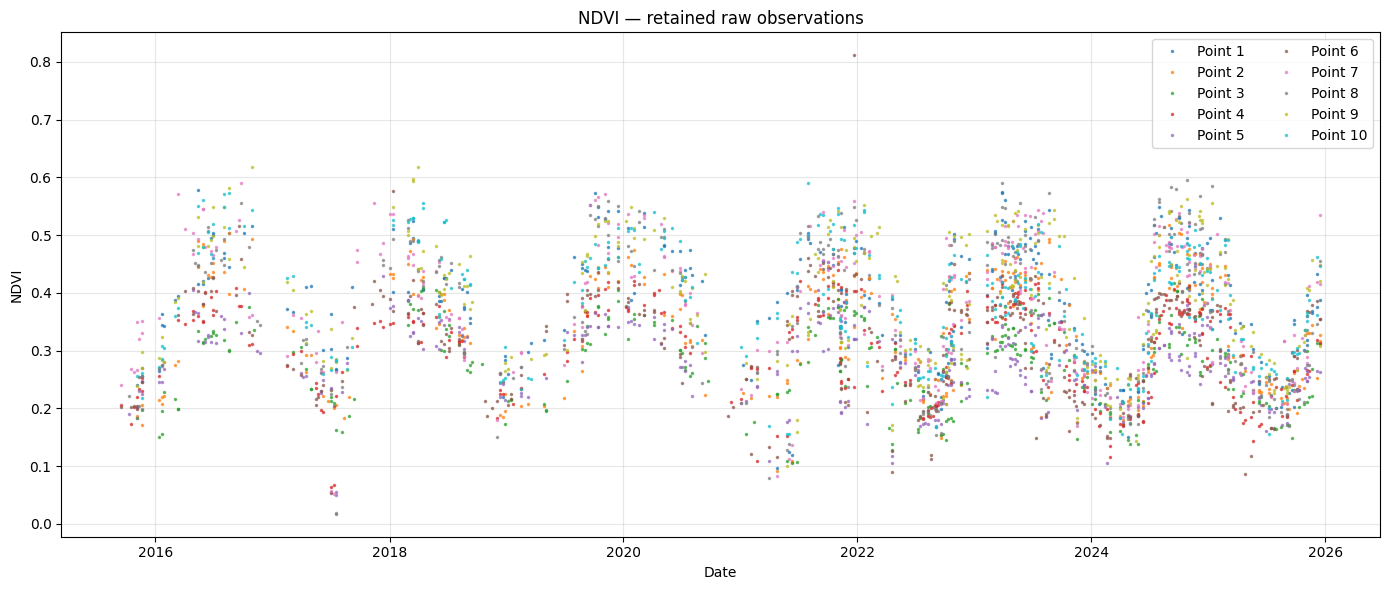

In [25]:
if VALUE_COL not in panel.columns:
    raise KeyError(
        f"{VALUE_COL!r} is not available. Choose one of:\n"
        + ", ".join(sorted(panel.columns))
    )

fig, ax = plt.subplots(figsize=(14, 6))

for point_id, group in panel.groupby("point_id"):
    ax.plot(
        group["date"],
        group[VALUE_COL],
        marker=".",
        linestyle="none",
        markersize=3,
        alpha=0.65,
        label=f"Point {point_id}",
    )

ax.set_title(f"{VALUE_COL} — retained raw observations")
ax.set_xlabel("Date")
ax.set_ylabel(VALUE_COL)
ax.grid(True, alpha=0.3)

if panel["point_id"].nunique() <= 10:
    ax.legend(ncol=2)

plt.tight_layout()
plt.show()


# 8. Temporal features and seasonal decomposition


In [26]:
series_by_point, features_df = build_regular_series(panel, VALUE_COL)

print(f"Temporal features for {len(features_df)} points on {VALUE_COL}")
display(features_df)


Temporal features for 10 points on NDVI


,n_steps,mean,std,cv,trend_slope,trend_r2,seasonal_amplitude,seasonal_phase,point_id
0,119,0.381907,0.084497,0.221250,-0.000445,0.032706,0.009395,1.684481,1
1,118,0.322228,0.091081,0.282659,-0.000092,0.001190,0.011954,1.095664,2
2,118,0.272197,0.066376,0.243852,-0.000188,0.009303,0.006522,1.475889,3
3,120,0.296572,0.071702,0.241771,-0.000254,0.015013,0.009170,1.387347,4
4,118,0.279927,0.059543,0.212710,-0.000549,0.098646,0.004190,1.778721,5
5,122,0.302261,0.085072,0.281452,-0.000383,0.025165,0.011803,1.331233,6
6,120,0.371984,0.101956,0.274086,-0.000536,0.033170,0.008318,1.410699,7
7,118,0.357206,0.109672,0.307026,-0.000276,0.007342,0.008431,1.613034,8
8,119,0.384182,0.094588,0.246206,-0.000484,0.030885,0.012366,0.848441,9
9,118,0.378445,0.095485,0.252309,-0.000696,0.061716,0.011175,1.474608,10


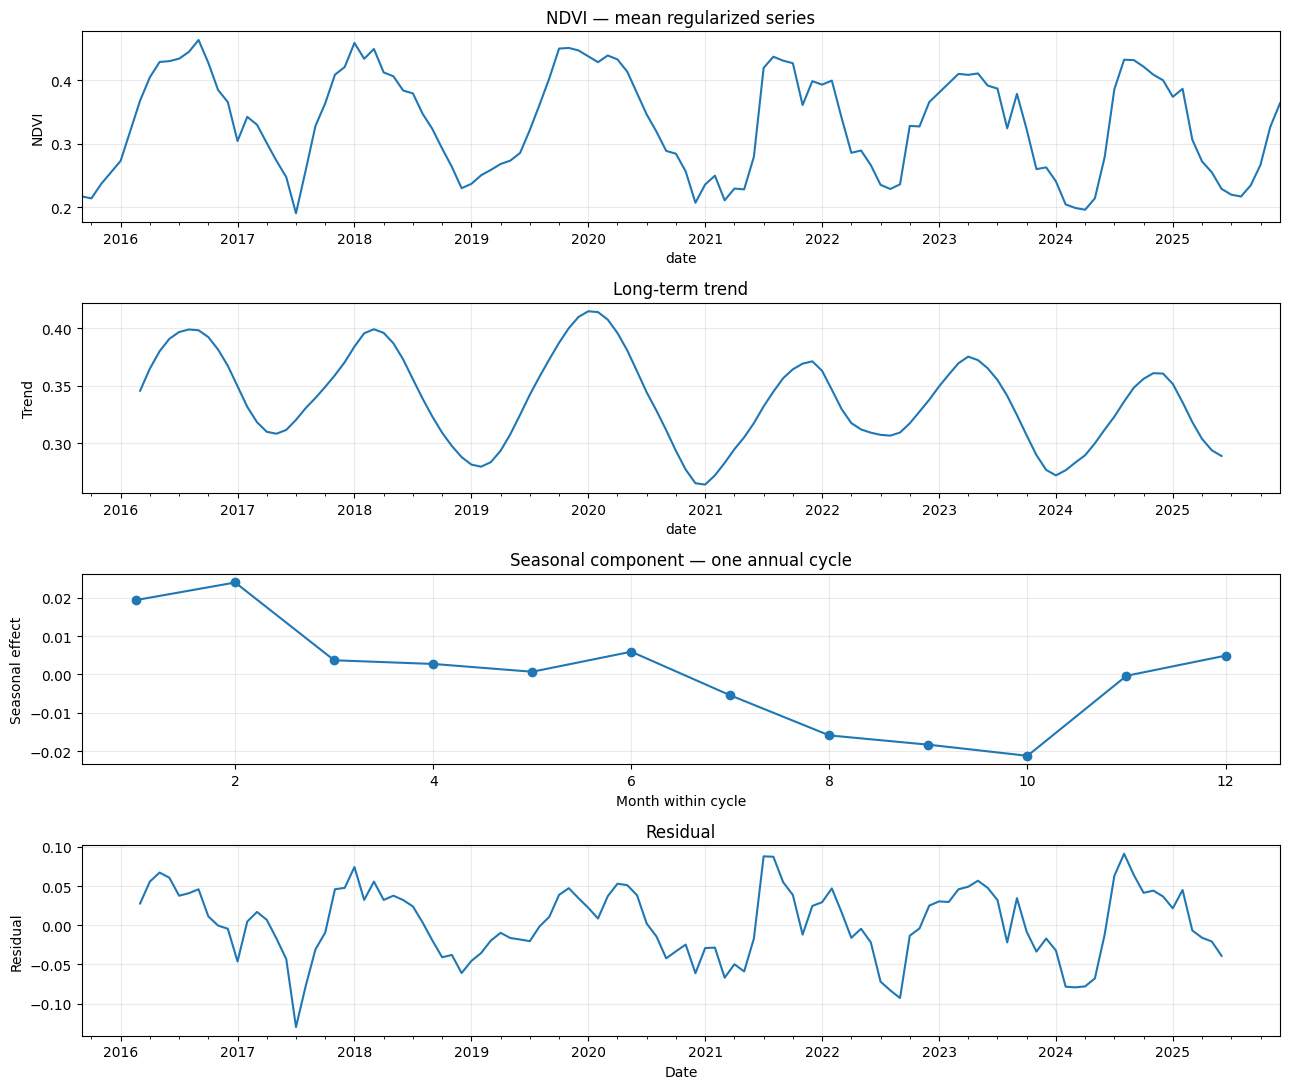

In [27]:
regular_panel = pd.DataFrame(series_by_point)
mean_series = regular_panel.mean(axis=1).dropna()

if len(mean_series) < SEASONAL_PERIOD * 2:
    raise ValueError(
        f"{VALUE_COL} needs at least {SEASONAL_PERIOD * 2} regular observations "
        "for seasonal decomposition."
    )

decomposition = seasonal_decompose(
    mean_series,
    model="additive",
    period=SEASONAL_PERIOD,
)

fig, axes = plt.subplots(4, 1, figsize=(13, 11))

mean_series.plot(ax=axes[0], title=f"{VALUE_COL} — mean regularized series")
axes[0].set_ylabel(VALUE_COL)

decomposition.trend.plot(ax=axes[1], title="Long-term trend")
axes[1].set_ylabel("Trend")

seasonal_cycle = decomposition.seasonal.iloc[:SEASONAL_PERIOD]
axes[2].plot(
    range(1, SEASONAL_PERIOD + 1),
    seasonal_cycle.values,
    marker="o",
)
axes[2].set_title("Seasonal component — one annual cycle")
axes[2].set_xlabel("Month within cycle")
axes[2].set_ylabel("Seasonal effect")

decomposition.resid.plot(ax=axes[3], title="Residual")
axes[3].set_xlabel("Date")
axes[3].set_ylabel("Residual")

for axis in axes:
    axis.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


# 9. Summary


In [28]:
print("=" * 60)
print("TEMPORAL ANALYSIS SUMMARY")
print("=" * 60)
print(f"Analysis period      : {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"Landsat sensors     : {', '.join(LANDSAT_TABLES)}")
print(f"QA mask applied     : {QA_MASK}")
print(f"Analyzed variable   : {VALUE_COL}")
print(f"Points analyzed     : {len(features_df)}")
print(f"Regular series span : {mean_series.index.min().date()} to {mean_series.index.max().date()}")
print(f"Regular steps       : {len(mean_series)}")
print(f"Seasonal period     : {SEASONAL_PERIOD}")
print(f"Mean trend slope    : {features_df['trend_slope'].mean():.6g} per step")
print(f"Mean seasonal amp.  : {features_df['seasonal_amplitude'].mean():.6g}")

conn.close()


TEMPORAL ANALYSIS SUMMARY
Analysis period      : 2015-09-16 to 2025-12-16
Landsat sensors     : landsat_8, landsat_9
QA mask applied     : True
Analyzed variable   : NDVI
Points analyzed     : 10
Regular series span : 2015-09-01 to 2025-12-01
Regular steps       : 124
Seasonal period     : 12
Mean trend slope    : -0.000390317 per step
Mean seasonal amp.  : 0.0093324
